📁 Please upload 'cats_vs_dogs.csv' file:


Saving cats_vs_dogs.csv to cats_vs_dogs.csv

✅ Dataset Loaded Successfully! Shape: (49, 13)

First 5 Rows:
        state  percent_dog_owners  percent_cat_owners  dog_population  \
0     Alabama                44.1                27.4            1410   
1     Arizona                40.1                29.6            1798   
2    Arkansas                47.9                30.6            1097   
3  California                32.8                28.3            6687   
4    Colorado                42.5                32.3            1349   

   cat_population  
0            1252  
1            1438  
2             810  
3            7118  
4            1191  

--- Model Evaluation Results ---
Accuracy Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

Cat Dominant       1.00      1.00      1.00         8
Dog Dominant       1.00      1.00      1.00         5

    accuracy                           1.00        13
   macro avg       1.00      1.00

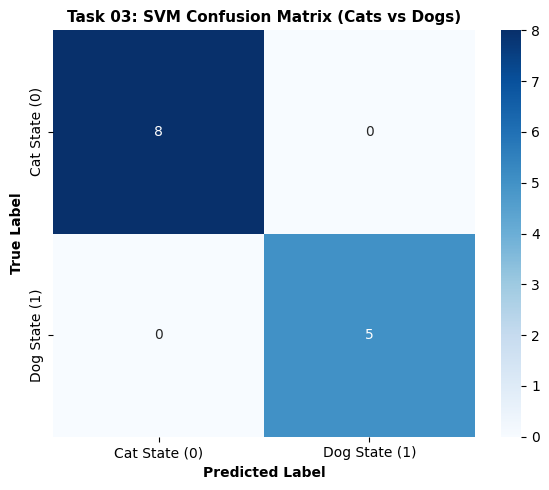

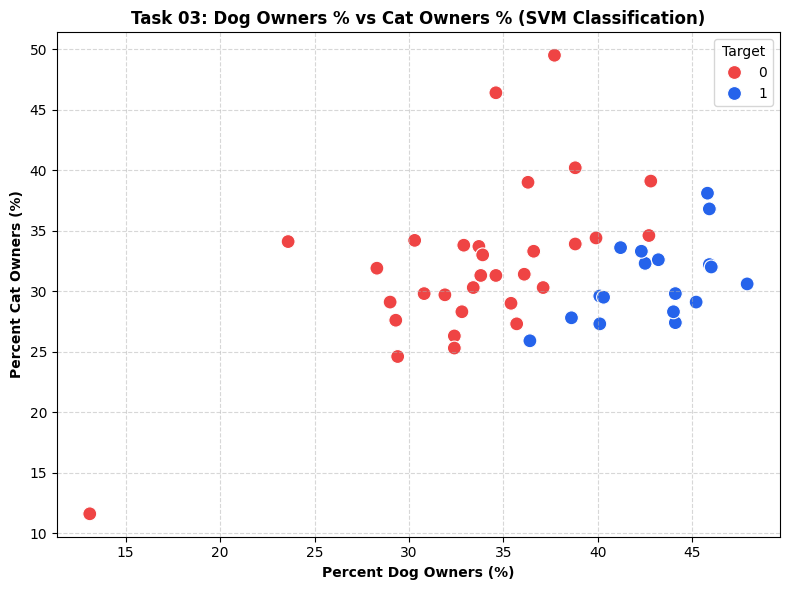


🎉 Both graphs ('confusion_matrix.png' & 'svm_feature_scatter.png') saved successfully!


In [2]:
# ==========================================
# PRODIGY INFOTECH - ML INTERNSHIP
# TASK 03: Cats vs Dogs Classification using SVM
# Author: Subham Kumar Swain
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import files

# 1. Upload cats_vs_dogs.csv file
print("📁 Please upload 'cats_vs_dogs.csv' file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("\n✅ Dataset Loaded Successfully! Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df[['state', 'percent_dog_owners', 'percent_cat_owners', 'dog_population', 'cat_population']].head())

# 2. Target Definition (1: Dog Dominant, 0: Cat Dominant)
df['Target'] = (df['dog_population'] > df['cat_population']).astype(int)

# Select Numeric Features for SVM Model
feature_cols = [
    'n_households', 'percent_pet_households',
    'percent_dog_owners', 'avg_dogs_per_household',
    'percent_cat_owners', 'avg_cats_per_household'
]

X = df[feature_cols]
y = df['Target']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split (75% Train, 25% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Train Support Vector Classifier (SVM)
model = SVC(kernel='linear', C=1.0, random_state=42)
model.fit(X_train, y_train)

# 5. Model Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"Accuracy Score: {acc * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Cat Dominant', 'Dog Dominant']))

# 6. Save Visualization 1: Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat State (0)', 'Dog State (1)'],
            yticklabels=['Cat State (0)', 'Dog State (1)'])
plt.title('Task 03: SVM Confusion Matrix (Cats vs Dogs)', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 7. Save Visualization 2: Feature Scatter Plot & Decision Boundary
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='percent_dog_owners', y='percent_cat_owners',
    hue='Target', palette=['#EF4444', '#2563EB'], s=100
)
plt.title('Task 03: Dog Owners % vs Cat Owners % (SVM Classification)', fontsize=12, fontweight='bold')
plt.xlabel('Percent Dog Owners (%)', fontweight='bold')
plt.ylabel('Percent Cat Owners (%)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('svm_feature_scatter.png', dpi=300)
plt.show()

print("\n🎉 Both graphs ('confusion_matrix.png' & 'svm_feature_scatter.png') saved successfully!")